<a href="https://colab.research.google.com/github/leajag/2025_ML_EES/blob/main/final_project_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Common imports
import numpy as np
import matplotlib as plt
import pandas as pd
import os
import matplotlib.pyplot as plt

# Extra imports for data pre- processing
!pip install rasterio
import rasterio

!pip install geopandas
import geopandas as gpd

!pip install --upgrade pyshp

!pip install --upgrade shapely

!pip install --upgrade descartes

!pip install --upgrade rtree

from __future__ import print_function

from osgeo import ogr

#for CNN
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

from keras.utils import plot_model
from sklearn.model_selection import train_test_split



In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!ls /content/drive/MyDrive

'Albedo img'	    GEEDiT_export_LJ.geojson   ML_project_old	   'RGB img'
'Colab Notebooks'   ML_project		      'notebooks glacier'


# Data processing: train / test split, k-fold cross validation, training data augmentation

In [4]:
data = np.load("/content/drive/MyDrive/ML_project/data_arrays_rem4.npz")
X = data['X']
y = data['y']

In [5]:
y_labels = y[:, 0, 0]  # takes left upper pixel per image, to ensure, that all classes are in test set
print("Unique classes:", np.unique(y_labels))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y_labels)

# upper left pixel to adjust labels as for all pixels in one image same class
y_test = y_test[:,0,0]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Unique classes: [1 2 3 5]
X_train shape: (1067, 3, 128, 128)
X_test shape: (119, 3, 128, 128)
y_train shape: (1067, 128, 128)
y_test shape: (119,)


**k-fold Cross validation with data augmentation for train set:**

In [6]:
from sklearn.model_selection import StratifiedKFold # Generate test sets such that all contain the same distribution of classes, or as close as possible.

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # 5-Fold Stratified Cross Validation


In [7]:
#6 augmentations
import albumentations as A

augmentations = [
    A.Compose([A.RandomRotate90(p=1.0)]),
    A.Compose([A.HorizontalFlip(p=1.0)]),
    A.Compose([A.VerticalFlip(p=1.0)]),
    A.Compose([A.Transpose(p=1.0)]),
    A.Compose([A.RandomBrightnessContrast(0.1, 0.1, p=1.0)]),
    A.Compose([A.GaussNoise(var_limit=(10, 30), p=1.0)])
]


/tmp/ipython-input-1131253907.py:10: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.Compose([A.GaussNoise(var_limit=(10, 30), p=1.0)])


In [8]:
folds = []

for fold_i, (train_idx, val_idx) in enumerate(kf.split(X, y_labels)):

    print(f"\n===== FOLD {fold_i+1} =====")

    X_train_raw = X[train_idx]
    y_train_raw = y_labels[train_idx]

    X_val = X[val_idx]
    y_val = y_labels[val_idx]

    # Augmentation: 6× per training sample
    X_aug_list = []
    y_aug_list = []

    for i in range(len(X_train_raw)):
        img = np.moveaxis(X_train_raw[i], 0, -1)   # C,H,W → H,W,C
        label = y_train_raw[i]

        for aug in augmentations:
            augmented = aug(image=img)
            img_aug = augmented["image"]

            img_aug = np.moveaxis(img_aug, -1, 0)  # zurück zu C,H,W

            X_aug_list.append(img_aug)
            y_aug_list.append(label)

    # Combine original + augmented
    X_train = np.concatenate([X_train_raw, np.array(X_aug_list)], axis=0)
    y_train = np.concatenate([y_train_raw, np.array(y_aug_list)], axis=0)

    print("Train raw:", len(X_train_raw))
    print("Train augmented:", len(X_train))
    print("Validation:", len(X_val))

    folds.append((X_train, y_train, X_val, y_val))

print("\n✓ Saved 5-fold augmented dataset.")



===== FOLD 1 =====
Train raw: 948
Train augmented: 6636
Validation: 238

===== FOLD 2 =====
Train raw: 949
Train augmented: 6643
Validation: 237

===== FOLD 3 =====
Train raw: 949
Train augmented: 6643
Validation: 237

===== FOLD 4 =====
Train raw: 949
Train augmented: 6643
Validation: 237

===== FOLD 5 =====
Train raw: 949
Train augmented: 6643
Validation: 237

✓ Saved 5-fold augmented dataset.


In [9]:

# Ordner, der bereits existiert
save_dir = "/content/drive/MyDrive/ML_project"

# Funktion zum Speichern
def save_split(X, y, name):
    save_path = os.path.join(save_dir, f"{name}.npz")
    np.savez_compressed(save_path, X=X, y=y)
    print(f"{name} gespeichert unter: {save_path}")
    print(f"  X shape: {X.shape}")
    print(f"  y shape: {y.shape}")

# Speichern der Splits
save_split(X_train, y_train, "train")
save_split(X_val,   y_val,   "val")
save_split(X_test,  y_test,  "test")


train gespeichert unter: /content/drive/MyDrive/ML_project/train.npz
  X shape: (6643, 3, 128, 128)
  y shape: (6643,)
val gespeichert unter: /content/drive/MyDrive/ML_project/val.npz
  X shape: (237, 3, 128, 128)
  y shape: (237,)
test gespeichert unter: /content/drive/MyDrive/ML_project/test.npz
  X shape: (119, 3, 128, 128)
  y shape: (119,)


In [10]:
#shapes
print("X train", X_train.shape)
print("X validation", X_val.shape)
print("X test", X_test.shape)

print("y train", y_train.shape)
print("y validation", y_val.shape)
print("y test", y_test.shape)


X train (6643, 3, 128, 128)
X validation (237, 3, 128, 128)
X test (119, 3, 128, 128)
y train (6643,)
y validation (237,)
y test (119,)


# train, val, test set directly from google drive

In [12]:
import numpy as np
import os

# Pfad zu deinem Ordner
load_dir = "/content/drive/MyDrive/ML_project"


# Hilfsfunktion zum Laden
def load_split(name):
    path = os.path.join(load_dir, f"{name}.npz")
    data = np.load(path)
    X = data["X"]
    y = data["y"]
    print(f"{name} geladen:")
    print("  X shape:", X.shape)
    print("  y shape:", y.shape)
    return X, y

# Laden aller Splits
X_train, y_train = load_split("train")
X_val,   y_val   = load_split("val")
X_test,  y_test  = load_split("test")


train geladen:
  X shape: (6643, 3, 128, 128)
  y shape: (6643,)
val geladen:
  X shape: (237, 3, 128, 128)
  y shape: (237,)
test geladen:
  X shape: (119, 3, 128, 128)
  y shape: (119,)


# **Logistic Regression:**

In [ ]:
#flatten layer for LR and RFC to 2D array
# Flatten X_fold_train from (samples, channels, height, width) to (samples, features)

# Flatten X
X_train_flat = X_train.reshape(len(X_train), -1) #X_train_flat.shape = (6643, 3*128*128) = (6643, 49152) #6643: number of images
X_val_flat   = X_val.reshape(len(X_val), -1)
X_test_flat  = X_test.reshape(len(X_test), -1)

#testing shapes
print("X_train_flat:", X_train_flat.shape)
print("X_val_flat:", X_val_flat.shape)
print("X_test_flat:", X_test_flat.shape)
print(" ")
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

X_train_flat: (6643, 49152)
X_val_flat: (237, 49152)
X_test_flat: (119, 49152)
 
y_train: (6643,)
y_val: (237,)
y_test: (119,)


In [ ]:
X_train_flat[1:4] #line 1: image 1 with all pixel values, starts with band R -> R_1: 81, R_2:39, then Green then Blue

array([[ 81,  39,  50, ...,  24,  16,  12],
       [ 78,  40,  78, ...,  42,  93, 103],
       [ 32,  50,  64, ...,  31,  36,  34]], dtype=uint8)

In [ ]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(multi_class = "multinomial",max_iter=1000, random_state=42)
clf.fit(X_train_flat, y_train) #takes: 5min


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial', random_state=42)

In [ ]:
#accuracy on validation set
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

clf_preds = clf.predict(X_val_flat)
clf_acc = accuracy_score(y_val, clf_preds)
print("CLF accuracy score:", clf_acc)


CLF accuracy score: 0.6244725738396625


# **Random Forest:**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(max_depth=10, random_state=42, min_samples_leaf = 5, max_features = "sqrt")
rfc.fit(X_train_flat, y_train) #took 3min

RandomForestClassifier(max_depth=10, min_samples_leaf=8, min_samples_split=8,
                       n_estimators=150, n_jobs=-1, oob_score=True,
                       random_state=42)

In [ ]:
#trying reducing overfitting
rfc = RandomForestClassifier(
    n_estimators=150,
    max_depth=10,          # kleiner als bisher
    min_samples_split=8,   # größere Splits
    min_samples_leaf=8,    # glättet Blätter
    max_features='sqrt',
    oob_score=True,
    random_state=42,
    n_jobs=-1
)
rfc.fit(X_train_flat, y_train) #took 2min -> increased validation accuracy

In [ ]:
#accuracy on validation set
rfc_preds = rfc.predict(X_val_flat)
rfc_acc = accuracy_score(y_val, rfc_preds)
print("RF accuracy score:", rfc_acc)


RF accuracy score: 0.6835443037974683


In [ ]:
#learning curve: check for overfitting
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import learning_curve

#from: https://www.datacamp.com/tutorial/tutorial-learning-curves
random_forest = RandomForestRegressor(max_depth=3)

train_sizes, train_scores, test_scores = learning_curve(estimator = rfc,
    X=X_train_flat, y=y_train,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1)

plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Train Accuracy')
plt.plot(train_sizes, np.mean(test_scores, axis=1), label='Validation Accuracy')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

KeyboardInterrupt: 

In [ ]:
#dauert ev weniger lange
train_sizes, train_scores, val_scores = learning_curve(
    RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42),
    X_train_flat, y_train,
    cv=3,  # weniger CV-Folds
    scoring="accuracy",
    train_sizes=[0.1,0.3,0.5,0.7,1.0],
    n_jobs=-1)


KeyboardInterrupt: 

In [ ]:
#hyperparameter training
#RandomizedSearchCV for hyperparameter search (RF) -> over 20min
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

rfc = RandomForestClassifier(random_state=42)

param_dist = {
    'n_estimators': randint(100, 200),
    'max_depth': [10, 20],
    'min_samples_split': randint(2, 5),
    'min_samples_leaf': randint(2, 5),
    'max_features': ['sqrt']
}

random_search = RandomizedSearchCV(
    estimator=rfc,
    param_distributions=param_dist,
    n_iter=5,
    cv=3,                               #cross validation with 3 folds: splits training set in training and validation
    n_jobs=-1,
    verbose=2,
    scoring='accuracy',
    random_state=42
)

random_search.fit(X_train_flat, y_train)
print("best parameters:",random_search.best_params_)
print("best score:", random_search.best_score_)



Fitting 3 folds for each of 5 candidates, totalling 15 fits


KeyboardInterrupt: 

In [ ]:
#accuracy on training set
rfc_preds1 = rfc.predict(X_train_flat)
rfc_acc1 = accuracy_score(y_train, rfc_preds1)
print("RF accuracy score:", rfc_acc1)


RF accuracy score: 0.9533343368959807


<Figure size 600x500 with 0 Axes>

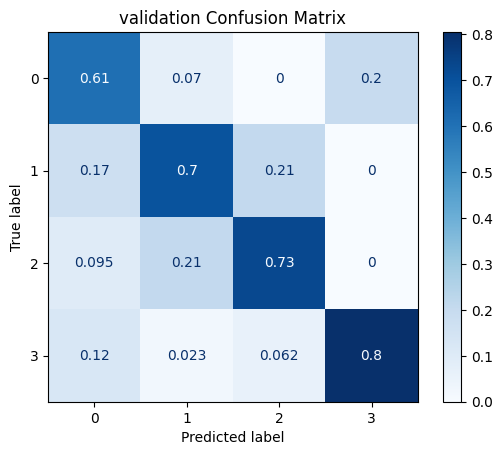

<Figure size 600x500 with 0 Axes>

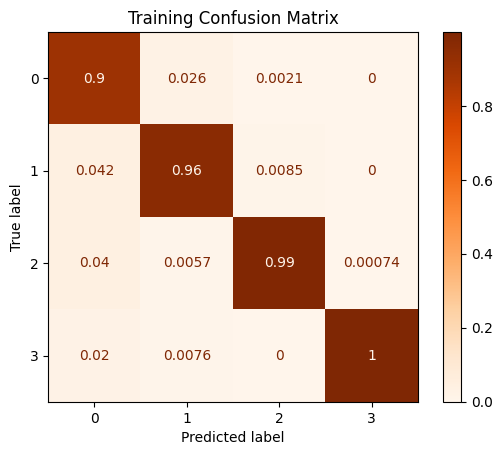

In [ ]:
#confusion matrix: validation
cm = confusion_matrix(y_val, rfc_preds, normalize="pred") # Get a confusion matrix 'cm', use 'pred' for the normalize option
disp = ConfusionMatrixDisplay(confusion_matrix = cm) # Use ConfusionMatrixDisplay to visualize 'cm'
#disp.plot()

plt.figure(figsize=(6,5))
disp.plot(cmap=plt.cm.Blues)
plt.title("validation Confusion Matrix")
plt.show()

#cm for training
cm_train = confusion_matrix(y_train, rfc_preds1, normalize="pred")  # normalize by predicted
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train)
plt.figure(figsize=(6,5))
disp_train.plot(cmap=plt.cm.Oranges)
plt.title("Training Confusion Matrix")
plt.show()


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# --- Train Confusion Matrix ---
cm_train = confusion_matrix(y_train, y_train_pred, normalize="pred")  # normalize by predicted
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train)
plt.figure(figsize=(6,5))
disp_train.plot(cmap=plt.cm.Blues)
plt.title("Train Confusion Matrix")
plt.show()

# --- Validation Confusion Matrix ---
cm_val = confusion_matrix(y_val, rfc_preds, normalize="pred")  # normalize by predicted
disp_val = ConfusionMatrixDisplay(confusion_matrix=cm_val)
plt.figure(figsize=(6,5))
disp_val.plot(cmap=plt.cm.Oranges)
plt.title("Validation Confusion Matrix")
plt.show()


NotFittedError: This RandomForestClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

## **CNN:**
# model1

In [13]:
# Reorganisation for Keras: transpose X_train and X-valid to (batch, height, width, channels)
X_train_trans = np.transpose(X_train, (0, 2, 3, 1))
X_val_trans = np.transpose(X_val, (0, 2, 3, 1))
X_test_trans = np.transpose(X_test, (0, 2, 3, 1))

#relabeling target: class 1 -> 0, class 2 -> 1, class 3 -> 3, class 5 -> 3
label_mapping = {1: 0, 2: 1, 3: 2, 5: 3}
y_train_relabeled = np.vectorize(label_mapping.get)(y_train)
y_val_relabeled = np.vectorize(label_mapping.get)(y_val)
y_test_relabeled = np.vectorize(label_mapping.get)(y_test)

In [14]:
model1 = tf.keras.Sequential()
input_img_shape = (X_train.shape[2], X_train.shape[3], X_train.shape[1]) #reorganisation of channels for Keras

In [15]:
#layers from 5.2 lab
#first layer: 16 filters, a 3x3 kernel size, a ReLU activation function and 'SAME' padding, weights are initialised by providing the input_shape argument in the first layer.
model1.add(tf.keras.layers.Conv2D(16,(3,3),padding='SAME', activation='relu',input_shape=input_img_shape,name='conv_1'))
model1.add(tf.keras.layers.Conv2D(8,(3,3),padding='SAME', activation='relu',name='conv_2'))
model1.add(MaxPooling2D((8,8),name='pool_1'))
model1.add(tf.keras.layers.Flatten(name='flatten'))
model1.add(tf.keras.layers.Dense(32, activation='relu',name='dense_1'))
model1.add(tf.keras.layers.Dense(4,activation='softmax',name='dense_2'))
model1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 128, 128, 8)    │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │        65,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,308 (262.92 KB)

 Trainable params: 67,308 (262.92 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model1.compile(optimizer='adam',
                  loss = 'sparse_categorical_crossentropy',
                  metrics = ['accuracy'])

In [17]:
epochs = 15

history_model1 = model1.fit(X_train_trans, y_train_relabeled,
                    epochs=epochs,
                    verbose=1,
                    validation_data=(X_val_trans, y_val_relabeled))

Epoch 1/15
208/208 ━━━━━━━━━━━━━━━━━━━━ 119s 562ms/step - accuracy: 0.2974 - loss: 11.2822 - val_accuracy: 0.3882 - val_loss: 1.2615
Epoch 2/15
208/208 ━━━━━━━━━━━━━━━━━━━━ 123s 592ms/step - accuracy: 0.4351 - loss: 1.2413 - val_accuracy: 0.5190 - val_loss: 1.0767
Epoch 3/15
208/208 ━━━━━━━━━━━━━━━━━━━━ 134s 644ms/step - accuracy: 0.5230 - loss: 1.0136 - val_accuracy: 0.5907 - val_loss: 1.0174
Epoch 4/15
208/208 ━━━━━━━━━━━━━━━━━━━━ 115s 553ms/step - accuracy: 0.5898 - loss: 0.9049 - val_accuracy: 0.6034 - val_loss: 0.9204
Epoch 5/15
208/208 ━━━━━━━━━━━━━━━━━━━━ 121s 582ms/step - accuracy: 0.6657 - loss: 0.7491 - val_accuracy: 0.6878 - val_loss: 0.7976
Epoch 6/15
208/208 ━━━━━━━━━━━━━━━━━━━━ 117s 564ms/step - accuracy: 0.7011 - loss: 0.6658 - val_accuracy: 0.6878 - val_loss: 0.7670
Epoch 7/15
208/208 ━━━━━━━━━━━━━━━━━━━━ 141s 562ms/step - accuracy: 0.7275 - loss: 0.6357 - val_accuracy: 0.7046 - val_loss: 0.7621
Epoch 8/15
208/208 ━━━━━━━━━━━━━━━━━━━━ 138s 545ms/step - accuracy: 0.7495 

In [20]:
score_model1 = model1.evaluate(X_test_trans, y_test_relabeled)
print('Test accuracy: {acc:0.3f}'.format(acc=score_model1[1]))

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 280ms/step - accuracy: 0.9216 - loss: 0.3817
Test accuracy: 0.916


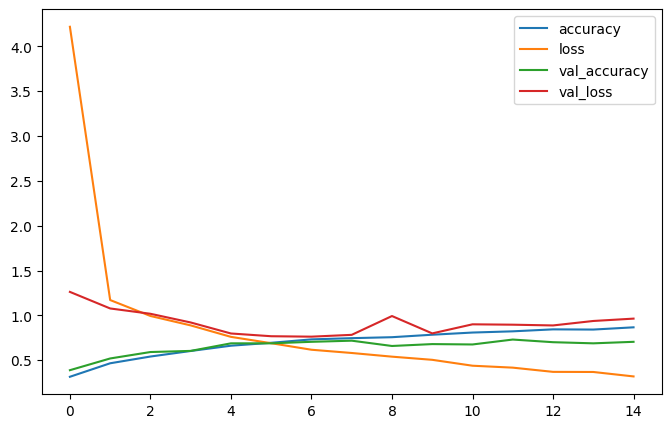

In [21]:
pd.DataFrame(history_model1.history).plot(figsize=(8,5))
plt.show()

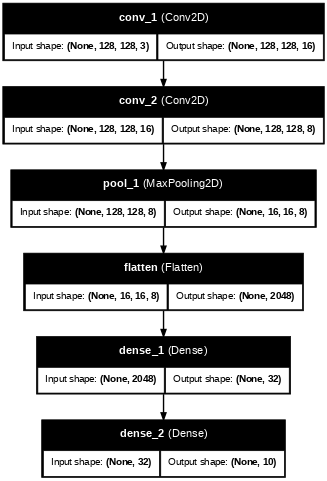

In [ ]:
# Plot the model using Keras model plotting utilities
tf.keras.utils.plot_model(model1, show_shapes=True, show_layer_names=True, dpi=50 )

# Model 1: Implement callbacks

In [ ]:
path_every = 'checkpoints_every_epoch/checkpoint_{epoch:03d}.weights.h5'
checkpoint_every_epoch = ModelCheckpoint(filepath=path_every,
                           save_freq="epoch",
                           save_weights_only=True,
                           monitor = "loss",
                           verbose=0)

In [ ]:
path_best = 'checkpoints_best_only/checkpoint.weights.h5'
checkpoint_best_only = ModelCheckpoint(filepath=path_best,
                           save_freq="epoch",
                           save_weights_only=True,
                           save_best_only = True,
                           monitor = "val_accuracy",
                           verbose=1)

In [ ]:
model = Sequential([
        Conv2D(16,(3,3),padding='SAME', activation='relu',input_shape=input_img_shape,name='conv_1'),
        Conv2D(8,(3,3),padding='SAME', activation='relu',input_shape=input_img_shape,name='conv_2'),
        MaxPooling2D((8,8),name='pool_1'),
        Flatten(name='flatten'),
        Dense(32, activation='relu',name='dense_1'),
        Dense(4,activation='softmax',name='dense_2')
    ])

model.compile(optimizer='adam',
                  loss = 'sparse_categorical_crossentropy',
                  metrics = ['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
callbacks = [checkpoint_every_epoch, checkpoint_best_only]

history_callback = model.fit(X_train_trans, y_train_relabeled,
                    epochs=15,
                    validation_data=(X_val_trans, y_val_relabeled),
                    callbacks = callbacks)

Epoch 1/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2478 - loss: 10.1351
Epoch 1: val_accuracy improved from -inf to 0.33333, saving model to checkpoints_best_only/checkpoint.weights.h5
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.2481 - loss: 10.0551 - val_accuracy: 0.3333 - val_loss: 1.5874
Epoch 2/40
70/72 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3912 - loss: 1.4824
Epoch 2: val_accuracy improved from 0.33333 to 0.48264, saving model to checkpoints_best_only/checkpoint.weights.h5
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.3933 - loss: 1.4790 - val_accuracy: 0.4826 - val_loss: 1.3591
Epoch 3/40
67/72 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5265 - loss: 1.1902
Epoch 3: val_accuracy improved from 0.48264 to 0.50694, saving model to checkpoints_best_only/checkpoint.weights.h5
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5274 - loss: 1.1869 - val_accuracy: 0.5069 - val_loss: 1.2054
Epoch 4/40
67/72 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step -

In [ ]:
#new model using above structure
model_last_epoch = Sequential([
        Conv2D(16,(3,3),padding='SAME', activation='relu',input_shape=input_img_shape,name='conv_1'),
        Conv2D(8,(3,3),padding='SAME', activation='relu',name='conv_2'),
        MaxPooling2D((8,8),name='pool_1'),
        Flatten(name='flatten'),
        Dense(32, activation='relu',name='dense_1'),
        Dense(4,activation='softmax',name='dense_2')
    ])
model_last_epoch.compile(optimizer='adam',
                  loss = 'sparse_categorical_crossentropy',
                  metrics = ['accuracy'])

# Load on the weights from the last training epoch.
model_last_epoch.load_weights("checkpoints_every_epoch/checkpoint_015.weights.h5")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
model_best_epoch = Sequential([
        Conv2D(16,(3,3),padding='SAME', activation='relu',input_shape=input_img_shape,name='conv_1'),
        Conv2D(8,(3,3),padding='SAME', activation='relu',name='conv_2'),
        MaxPooling2D((8,8),name='pool_1'),
        Flatten(name='flatten'),
        Dense(32, activation='relu',name='dense_1'),
        Dense(4,activation='softmax',name='dense_2')
    ])
model_best_epoch.compile(optimizer='adam',
                  loss = 'sparse_categorical_crossentropy',
                  metrics = ['accuracy'])

# Load the weights leading to the highest validation accuracy.
model_best_epoch.load_weights('checkpoints_best_only/checkpoint.weights.h5')

In [ ]:
#Verify that the validation accuarcy of the last and the best model.
score_model_last_epoch = model_last_epoch.evaluate(X_val_trans, y_val_relabeled)
print('Model validation accuracy with last epoch weights: {acc:0.3f}'.format(acc=score_model_last_epoch[1]))
print('')
score_model_best_epoch = model_best_epoch.evaluate(X_val_trans, y_val_relabeled)
print('Model validation accuracy with best epoch weights: {acc:0.3f}'.format(acc=score_model_best_epoch[1]))

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5968 - loss: 1.6861
Model validation accuracy with last epoch weights: 0.639

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6437 - loss: 2.7022
Model validation accuracy with best epoch weights: 0.667


In [ ]:
model_callback_best_epoch = model_best_epoch.evaluate(X_test_trans, y_test_relabeled)
print('Test accuracy - early stopping: {acc:0.3f}'.format(acc=model_callback_best_epoch[1]))


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6280 - loss: 2.7380 
Test accuracy - early stopping: 0.584


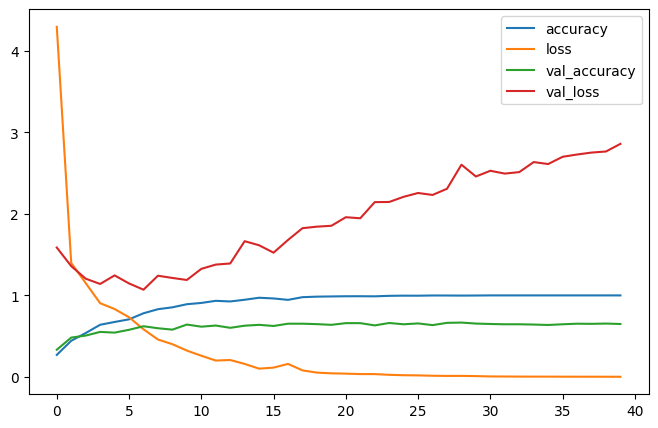

In [ ]:
pd.DataFrame(history_callback.history).plot(figsize=(8,5))
plt.show()

# Model 2: to improve model performance by trying to reduce the bias -> more complex model

In [27]:
#has the same structure as model1, but with more convolution units:
#conv_1 has 32 units, conv_2 has 64 units, dense_1 with 256 units

model2 = Sequential([
        Conv2D(32,(3,3),padding='SAME', activation='relu',input_shape=input_img_shape,name='conv_1'),
        Conv2D(64,(3,3),padding='SAME', activation='relu',input_shape=input_img_shape,name='conv_2'),
        MaxPooling2D((8,8),name='pool_1'),
        Flatten(name='flatten'),
        Dense(256, activation='relu',name='dense_1'),
        Dense(4,activation='softmax',name='dense_2')
    ])
model2.compile(optimizer='adam',
                  loss = 'sparse_categorical_crossentropy',
                  metrics = ['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [28]:
history_model2 = model2.fit(X_train_trans, y_train_relabeled,
                     epochs=8,
                     verbose = 1,
                     validation_data=(X_val_trans, y_val_relabeled))


Epoch 1/8
  5/208 ━━━━━━━━━━━━━━━━━━━━ 11:19 3s/step - accuracy: 0.3038 - loss: 504.0843

KeyboardInterrupt: 

In [ ]:
score_model2 = model2.evaluate(X_test_trans, y_test_relabeled)
print('Test accuracy: {acc:0.3f}'.format(acc=score_model2[1])) #-> improved!

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6965 - loss: 1.8693
Test accuracy: 0.703


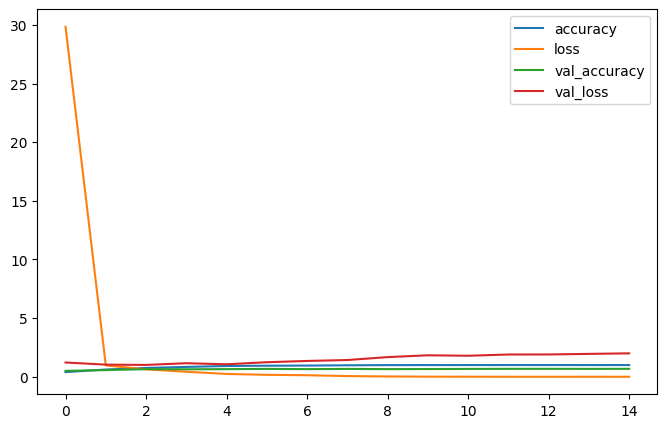

In [ ]:
pd.DataFrame(history_model2.history).plot(figsize=(8,5))
plt.show()

# Model 3: with reduced variance by dropout

In [ ]:
#has the same structure as model2, but dropout layers one after the max pooling layer,
#one before the final dense layer with dropout rate of 0.2

model3 = Sequential([
        Conv2D(32,(3,3),padding='SAME', activation='relu',input_shape=input_img_shape,name='conv_1'),
        Conv2D(64,(3,3),padding='SAME', activation='relu',input_shape=input_img_shape,name='conv_2'),
        MaxPooling2D((8,8),name='pool_1'),
        Dropout(rate = 0.2),
        Flatten(name='flatten'),
        Dense(256, activation='relu',name='dense_1'),
        Dropout(rate = 0.2),
        Dense(4,activation='softmax',name='dense_2')
    ])
model3.compile(optimizer='adam',
                  loss = 'sparse_categorical_crossentropy',
                  metrics = ['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history_model3 = model3.fit(X_train_trans, y_train_relabeled,
                     epochs=15,
                     verbose = 0,
                     validation_data=(X_val_trans, y_val_relabeled))



Epoch 1/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 10s 57ms/step - accuracy: 0.2930 - loss: 98.1299 - val_accuracy: 0.6267 - val_loss: 1.0423
Epoch 2/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.5929 - loss: 0.9907 - val_accuracy: 0.6285 - val_loss: 0.8891
Epoch 3/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.7106 - loss: 0.7351 - val_accuracy: 0.6806 - val_loss: 0.8634
Epoch 4/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.7652 - loss: 0.5895 - val_accuracy: 0.6719 - val_loss: 0.7805
Epoch 5/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.8238 - loss: 0.4710 - val_accuracy: 0.7413 - val_loss: 0.7548
Epoch 6/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.8872 - loss: 0.3197 - val_accuracy: 0.7431 - val_loss: 0.7130
Epoch 7/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.9212 - loss: 0.2224 - val_accuracy: 0.6910 - val_loss: 0.9886
Epoch 8/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9333 - loss: 0.1955 - val_accuracy: 0.6927 -

In [ ]:
score_model3 = model3.evaluate(X_test_trans, y_test_relabeled)
print('Test accuracy: {acc:0.3f}'.format(acc=score_model3[1]))

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6755 - loss: 1.7170
Test accuracy: 0.666


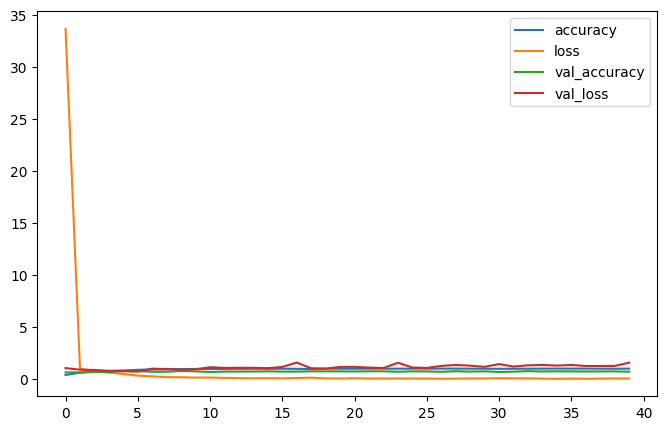

In [ ]:
pd.DataFrame(history_model3.history).plot(figsize=(8,5))
plt.show()

# Model 4: Improve model with transfer learning:

In [22]:
from keras.applications import VGG16

conv_base = VGG16(include_top=False, input_shape = input_img_shape)
# freeze the weights
for layer in conv_base.layers:
    layer.trainable = False

model4 = Sequential([
        conv_base,
        Flatten(name='flatten'),
        Dropout(0.2),
        Dense(256, activation='relu',name='dense_1'),
        Dropout(0.2),
        Dense(4,activation='softmax',name='dense_2')
    ])
model4.compile(optimizer='adam',
                  loss = 'sparse_categorical_crossentropy',
                  metrics = ['accuracy'])

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [23]:
history_model4 = model4.fit(X_train_trans, y_train_relabeled, #takes 4min
                     epochs=8,
                     validation_data=(X_val_trans, y_val_relabeled))



Epoch 1/8
  3/208 ━━━━━━━━━━━━━━━━━━━━ 30:17 9s/step - accuracy: 0.2569 - loss: 8.7677

KeyboardInterrupt: 

In [ ]:
score_model4 = model4.evaluate(X_test_trans, y_test_relabeled)
print('Test accuracy: {acc:0.3f}'.format(acc=score_model4[1]))

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.7946 - loss: 0.9672
Test accuracy: 0.762


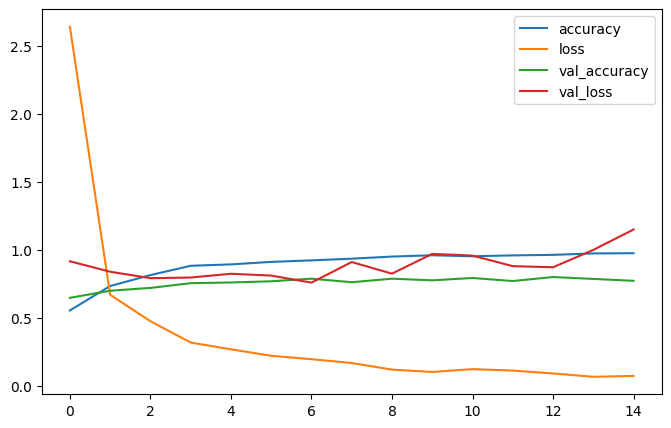

In [ ]:
pd.DataFrame(history_model4.history).plot(figsize=(8,5))
plt.show()

In [ ]:
#accuracy score comparison
print("CLF accuracy score:", clf_acc)
print("RF accuracy score:", rfc_acc)

print("CNN:")
print('Test accuracy model1: {acc:0.3f}'.format(acc=score_model1[1]))
print('')
print('Model validation accuracy with last epoch weights: {acc:0.3f}'.format(acc=score_model_last_epoch[1]))
print('')
print('Model validation accuracy with best epoch weights: {acc:0.3f}'.format(acc=score_model_best_epoch[1]))
print('')
print('Test accuracy model2 - reducing bias: {acc:0.3f}'.format(acc=score_model2[1]))
print('Test accuracy model3 - reducing variance: {acc:0.3f}'.format(acc=score_model3[1]))
print('Test accuracy model4 - transfer learning: {acc:0.3f}'.format(acc=score_model4[1]))



CLF accuracy score: 0.609375
RF accuracy score: 0.634375
CNN:
Test accuracy model1: 0.656

Model validation accuracy with last epoch weights: 0.637

Model validation accuracy with best epoch weights: 0.688

Test accuracy model2 - reducing bias: 0.656
Test accuracy model3 - reducing variance: 0.666
Test accuracy model4 - transfer learning: 0.762


In [ ]:
#shows one image

import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Pfad zum Raster
raster_path = "/content/drive/MyDrive/ML_project/data/d/class1/aug_0_1_poly_91.tif"

# Raster laden
with rasterio.open(raster_path) as src:
    img = src.read()  # shape: (4, H, W)
    profile = src.profile

# RGB extrahieren (erste 3 Bänder)
rgb = img[:3, :, :]

# Rasterio liest als (B, H, W) → matplotlib erwartet (H, W, B)
rgb = np.moveaxis(rgb, 0, -1)

# Optional: Werte auf 0-255 strecken, falls Max < 255
for i in range(3):
    band = rgb[:, :, i]
    rgb[:, :, i] = ((band - band.min()) / (band.max() - band.min()) * 255).astype(np.uint8)

# Plot
plt.figure(figsize=(5, 5))
plt.imshow(rgb)
plt.title("aug_0_0_poly_25 - class1 / Region r")
plt.axis('off')
plt.show()
